# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder, maybe_compile
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_alignment_evals, run_full_model_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=40.5,
    std_coeff=40.5,
    cov_coeff=1.62,
    pert_latent_dim= 320,
    pert_mode_dim= 64,
)

# Training configs
pt_cfg = PretrainConfig(epochs=50, lr=1e-4, batch_size=64) 
align_cfg = AlignmentConfig(epochs=10000, lr=7.6e-4, batch_size=64, weight_decay=0.011)
full_cfg = FullTrainingConfig(epochs=20, predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.15) 
decoder_cfg = DecoderConfig(epochs=10, lr=1e-3, batch_size=32) 

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,266
ACpredictor: 10,036,224
PerturbationComposer: 1,478,976


### Load pretraining model from checkpoint (for resuming)

In [5]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_align_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [6]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Pretraining

In [7]:
# decompress_npz(data_cfg.data_root / 'pretraining')

In [6]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device )
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device)

found 1123 shards for split train
shard balancing (threshold=67, 10% of max=668):
  adamson: 22 -> 88 shards (x4)
  k562e_raw: 48 -> 96 shards (x2)
  k562gw: 668 shards
  norman: 39 -> 78 shards (x2)
  rep1e: 80 shards
  sciplex: 266 shards
found 71 shards for split val


In [9]:
pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

Pretraining: 3266560 samples, 51040 steps/epoch, 2552000 total steps
Step 0 | val loss: 121.4402
Step 0 | Loss: 121.19118 | LR: 4.00e-06
Step 100 | Loss: 105.24300 | LR: 4.00e-06
Step 200 | Loss: 96.12017 | LR: 4.00e-06
Step 300 | Loss: 91.19173 | LR: 4.00e-06
Step 400 | Loss: 87.11095 | LR: 4.00e-06
Step 500 | val loss: 85.5136
Step 500 | Loss: 85.42489 | LR: 4.00e-06
Step 600 | Loss: 83.01083 | LR: 4.01e-06
Step 700 | Loss: 82.26267 | LR: 4.01e-06
Step 800 | Loss: 80.09735 | LR: 4.01e-06
Step 900 | Loss: 75.81263 | LR: 4.01e-06
Step 1000 | val loss: 74.9630
Step 1000 | Loss: 75.02205 | LR: 4.01e-06
Step 1100 | Loss: 72.97739 | LR: 4.02e-06
Step 1200 | Loss: 72.50298 | LR: 4.02e-06
Step 1300 | Loss: 70.59700 | LR: 4.02e-06
Step 1400 | Loss: 69.46648 | LR: 4.03e-06
Step 1500 | val loss: 69.7133
Step 1500 | Loss: 69.39615 | LR: 4.03e-06
Step 1600 | Loss: 67.87922 | LR: 4.04e-06
Step 1700 | Loss: 68.82796 | LR: 4.04e-06
Step 1800 | Loss: 66.97136 | LR: 4.05e-06
Step 1900 | Loss: 66.25498

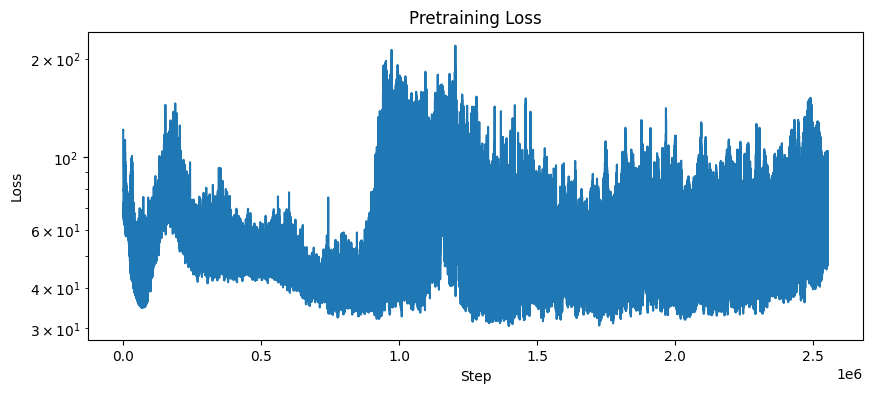

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [11]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Pretraining Evals

In [7]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': pt_cfg.batch_size, 'seed': SEED
})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.eval_results_dir / 'pretraining_eval_report.json')
pt_eval_results

Using cuda
found 121 shards for split test


batch_invariance: Extracting embeddings: 100%|███████████████| 4840/4840 [05:56<00:00, 13.58it/s]


Training classifiers...
batch_invariance: Batch=0.0588 (22.1x), Pert=0.0269 (29.2x)
batch_invariance summary: global_ratio=0.457, within_dataset_macro_ratio=0.538
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
gene_embedding_pathways: KEGG ratio=1.1287
essential_gene_prediction: Pearson=0.3104, AUROC=0.7098
found 121 shards for split test


cell_type_probing: Extracting embeddings: 100%|██████████████| 4840/4840 [05:53<00:00, 13.67it/s]


Training cell type classifier...
cell_type_probing: Accuracy=0.8902 (2.7x chance), Macro F1=0.7428
found 121 shards for split test


...

embedding_consistency: Extracting embeddings: 100%|██████████| 4840/4840 [05:54<00:00, 13.64it/s]


embedding_consistency: Computing intra-distances for 1127 perturbations...
embedding_consistency: Computing 5000 inter-distances...
embedding_consistency: Intra=9.7482, Inter=9.7733, Ratio=1.00x
embedding_consistency: Computing for dataset adamson...
embedding_consistency: Computing for dataset k562e_raw...
embedding_consistency: Computing for dataset k562gw...
embedding_consistency: Computing for dataset norman...
embedding_consistency: Computing for dataset sciplex...
found 121 shards for split test


latent_space_health: Extracting embeddings: 100%|████████████| 4840/4840 [05:52<00:00, 13.72it/s]


latent_space_health: Eff_dim_90=8/256, Mean_var=0.3432, Isotropy=0.000000
Saved report to /home/ubuntu/data/v0_6/eval_results/pretraining_eval_report_epoch38.json


{'batch_invariance': {'config': {'samples': 309760,
   'embedding_dim': 256,
   'num_batches': 376,
   'num_perturbations': 1089},
  'batch_classifier': {'accuracy': 0.058803589876033055,
   'chance': 0.0026595744680851063,
   'above_chance_ratio': 22.11014979338843},
  'perturbation_classifier': {'accuracy': 0.026859504132231406,
   'chance': 0.0009182736455463728,
   'above_chance_ratio': 29.25},
  'invariance_ratio': 0.45676640131759544,
  'by_dataset': {'k562e_raw': {'config': {'samples': 49066,
     'embedding_dim': 256,
     'num_batches': 48,
     'num_perturbations': 286},
    'batch_classifier': {'accuracy': 0.08335031587528022,
     'chance': 0.020833333333333332,
     'above_chance_ratio': 4.000815162013451},
    'perturbation_classifier': {'accuracy': 0.015488078255553291,
     'chance': 0.0034965034965034965,
     'above_chance_ratio': 4.429590381088241},
    'invariance_ratio': 0.18581907090464547},
   'k562gw': {'config': {'samples': 178474,
     'embedding_dim': 256,
  

In [8]:
# compress_npz(data_cfg.data_root / 'pretraining')

In [9]:
del pt_train_loader, pt_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 2: Perturbation Alignment

In [8]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
found 1 shards for split val


In [9]:
align_results = run_alignment(model, align_train_loader, align_val_loader, seq_banks, target_bank, align_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Alignment: 1250 samples, 19 steps/epoch, 190000 total steps
Step 0 | val loss: 11.8658
Step 0 | Loss: 12.59455 | LR: 3.04e-05
Step 100 | Loss: 3.99506 | LR: 3.06e-05
Step 200 | Loss: 3.91410 | LR: 3.12e-05
Step 300 | Loss: 4.10631 | LR: 3.22e-05
Step 400 | Loss: 3.96454 | LR: 3.36e-05
Step 500 | val loss: 3.6191
Step 500 | Loss: 3.90735 | LR: 3.54e-05
Step 600 | Loss: 3.85535 | LR: 3.76e-05
Step 700 | Loss: 4.16943 | LR: 4.02e-05
Step 800 | Loss: 3.93945 | LR: 4.31e-05
Step 900 | Loss: 4.01007 | LR: 4.65e-05
Step 1000 | val loss: 3.6105
Step 1000 | Loss: 3.89750 | LR: 5.02e-05
Step 1100 | Loss: 3.92130 | LR: 5.43e-05
Step 1200 | Loss: 4.15625 | LR: 5.88e-05
Step 1300 | Loss: 3.87085 | LR: 6.37e-05
Step 1400 | Loss: 4.02087 | LR: 6.89e-05
Step 1500 | val loss: 3.6032
Step 1500 | Loss: 3.93433 | LR: 7.44e-05
Step 1600 | Loss: 4.03003 | LR: 8.04e-05
Step 1700 | Loss: 4.05995 | LR: 8.66e-05
Step 1800 | Loss: 4.13403 | LR: 9.32e-05
Step 1900 | Loss: 4.08206 | LR: 1.00e-04
Step 2000 | val lo

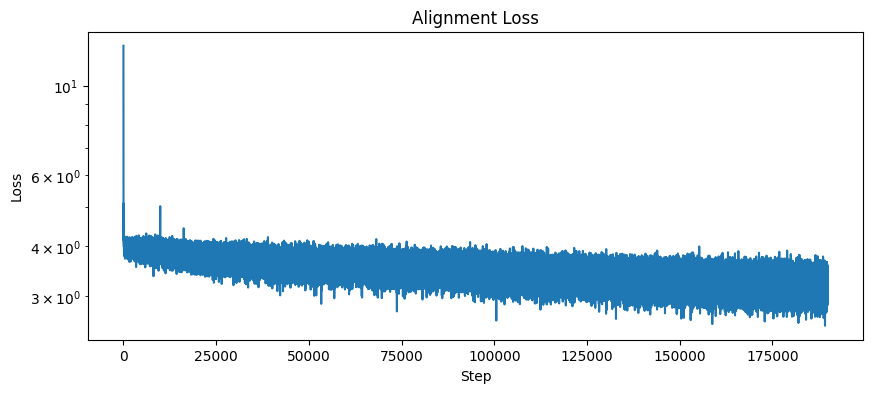

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Alignment Evals

In [11]:
align_eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': align_cfg.batch_size, 'seed': SEED
})
align_eval_results = run_alignment_evals(align_eval_ctx)

save_report(align_eval_results, data_cfg.eval_results_dir / 'alignment_eval_report.json')
align_eval_results

Using cuda
Loaded 10797 v0.6 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 320])
Encoded chemical sequences: torch.Size([188, 320])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 320])
seq_to_target_retrieval: dna_mrr=0.0055
cross_modality_target_consistency: Within=0.5727, Between=0.4564, Ratio=1.25x
seq_target_gap_analysis: dna_gap=2.03
paired_alignment_quality: dna_sim=-0.2228
mode_sensitivity: Classification_acc=0.9762 (6.8x chance)
fusion_quality: Fused_var=0.3615, Seq_var=0.2761, Target_var=0.0430
missing_data_robustness: Fused_MRR=0.0277, Seq_only=0.0049, Target_only=1.0000
found 121 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|██████████| 500/500 [00:03<00:00, 127.65it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0770, target_only=0.2783, fused=0.1855
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
action_vector_pathways DNA: ratio=1.0094705727219566
Saved report to /home/ubuntu/data/v0_6/eval_results/alignment_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.005549596904357844,
    'median_rank': 2266.0,
    'mean_rank': 2909.861913272505,
    'n_queries': 10631,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.0008465807543975167,
     '5': 0.005549807167717054,
     '10': 0.010723356222368545,
     '20': 0.018154453955413413,
     '50': 0.037249553193490735}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 915,
   'n_within_pairs': 1452,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.5727293491363525,
   'between_target_sim': 0.45639820601269604,
   'consistency_ratio': 1.2548895714117254}},
 'seq_target_gap_analysis': {'target_variance': 13.68704605102539,
  'n_targets': 9975,
  'dna': {'seq_variance': 89.747314453125,
   'centroid_distance': 24.435747146606445,
   'mean_within_seq': 13.030505532751976,
   'mean_seq_to_target': 26.41742706298828,
   'gap_ratio': 2.027352430539896,
   'n_sequences': 1

In [12]:
del align_train_loader, align_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Full Training

In [6]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device)

full_results = run_full_training(model, train_loader, val_loader, seq_banks, target_bank, full_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
shard balancing (threshold=129, 20% of max=643):
  adamson: 21 -> 147 shards (x7)
  k562e_raw: 48 -> 144 shards (x3)
  k562gw: 643 shards
  norman: 16 -> 144 shards (x9)
  sciplex: 248 shards
found 62 shards for split val
Full training: 3394560 samples, 106080 steps/epoch, 2121600 total steps
Mask annealing: starts at step 1803360 (0.766 -> 0.1)
Beta-NLL: target=0.20, anneal steps=636480
Step 0 | val loss: 210.4871
Step 0 | Loss: 189.81709 | LR: 4.00e-06 | Beta: 0.000
Step 100 | Loss: 138.18402 | LR: 4.00e-06 | Beta: 0.000
Step 200 | Loss: 130.45355 | LR: 4.00e-06 | Beta: 0.000
Step 300 | Loss: 138.25554 | LR: 4.00e-06 | Beta: 0.000
Step 400 | Loss: 125.82529 | LR: 4.00e-06 | Beta: 0.000
Step 500 | val loss: 130.1920
Step 500 | Loss: 135.98558 | LR: 4.01e-06 | Beta: 0.000
Step 600 | Loss: 117.38228 | LR: 4.01e-06 | Beta: 0.000
Step 700 | Loss: 131.51385 | LR: 4.01e-06 | Beta: 0.000
Step 800 | Loss: 119.02057 | LR: 4.01e-06 | Beta: 0.000
Step 900 | Loss:

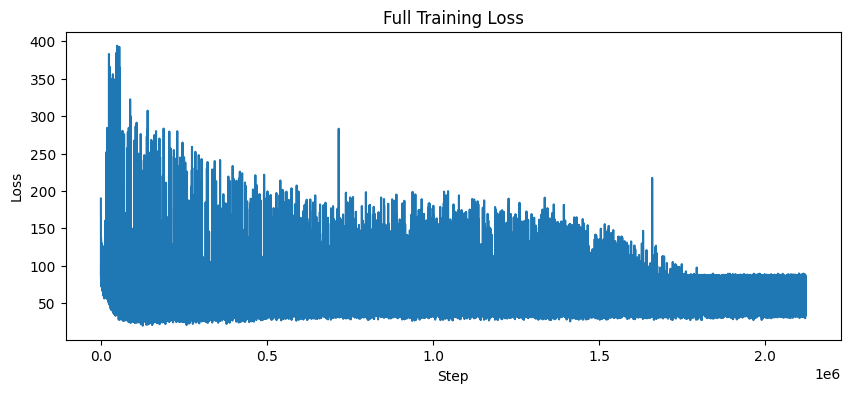

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [8]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [9]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'training',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
shard balancing (threshold=129, 20% of max=643):
  adamson: 21 -> 147 shards (x7)
  k562e_raw: 48 -> 144 shards (x3)
  k562gw: 643 shards
  norman: 16 -> 144 shards (x9)
  sciplex: 248 shards
found 62 shards for split val
Decoder Step 0 | val loss: 1.5564
Decoder Step 0 | Loss: 1.22569
Decoder Step 100 | Loss: 1.04534
Decoder Step 200 | Loss: 0.73024
Decoder Step 300 | Loss: 0.63415
Decoder Step 400 | Loss: 0.52386
Decoder Step 500 | val loss: 0.3661
Decoder Step 500 | Loss: 0.70121
Decoder Step 600 | Loss: 0.25824
Decoder Step 700 | Loss: 0.42233
Decoder Step 800 | Loss: 0.18416
Decoder Step 900 | Loss: 0.16275
Decoder Step 1000 | val loss: 0.1453
Decoder Step 1000 | Loss: 0.32722
Decoder Step 1100 | Loss: 0.12928
Decoder Step 1200 | Loss: 0.13176
Decoder Step 1300 | Loss: 0.31100
Decoder Step 1400 | Loss: 0.12686
Decoder Step 1500 | val loss: 0.2991
Decoder Step 1500 | Loss: 0.10022
Decoder Step 1600 | Loss: 0.08357
Decoder Step 1700 | Loss: 0.33575
D

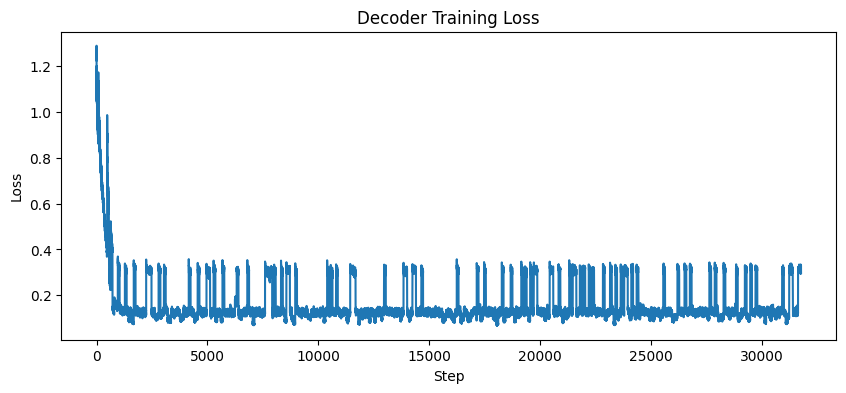

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Full Model Evals

In [11]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': full_cfg.batch_size, 'seed': SEED
})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.eval_results_dir / 'full_model_eval_report.json')
full_eval_results

Using cuda
found 121 shards for split test


Running test inference:   0%|                                           | 0/9680 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Loaded target bank: torch.Size([9975, 320])


Running test inference:   8%|██▌                              | 745/9680 [03:25<21:32,  6.91it/s]/home/ubuntu/code/biojepa/evals/evals.py:560: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|████████████████████████████████| 9680/9680 [42:34<00:00,  3.79it/s]


Aggregated 1119 single-pert, 8 multi-pert perturbations, 309760 samples, 121 shards
  adamson: 11 perturbations, 5331 samples
  k562e_raw: 286 perturbations, 49066 samples
  k562gw: 1053 perturbations, 178474 samples
  sciplex: 54 perturbations, 74203 samples
Cached test inference to /home/ubuntu/data/v0_6/test_inference_cache (121 shards)
expression_prediction: Pearson=0.9904, R2=0.9798, Centroid_acc=0.5967
gene_level_analysis: Dir_acc=0.9935, Top50_acc=0.7929


perturbation_retrieval (dna):  71%|████████████████▎      | 709/1000 [8:54:20<3:39:19, 45.22s/it]


KeyboardInterrupt: 

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')